# 4.2.1 阻尼受迫与自维持振荡

## 学习目标与先修知识

能通过方程与输入（input）对照区分阻尼、受迫和自维持振荡（self-sustained oscillation），从二维方程推导径向运动，并解释稳定极限环（limit cycle）与精确原点的例外。

先修：第 3 篇的二维旋转、复数（complex number）、链式法则（chain rule）和相图（phase portrait）；第 4.1 章的吸引域（basin of attraction）。 [复习上一节](../01-多稳态与吸引域/02-吸引域扰动与有限时间扫描.ipynb)。

## 具体问题

昼夜节律、周期性进食刺激和受扰动后的衰减，都可能画出“波”。怎样判断周期由外部时钟维持，还是由系统内部产生？先比较机制清楚的三个理想模型（model）。

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
radius=np.array([.1,.5,1.,1.5])
mu=.5
display(Markdown(show_table(['R','R(μ−R²)'],zip(radius,radius*(mu-radius**2)))))
print('半径小于 sqrt(0.5) 时增长，超过时下降。')

| R | R(μ−R²) |
| --- | --- |
| 0.1 | 0.049 |
| 0.5 | 0.125 |
| 1 | -0.5 |
| 1.5 | -2.625 |

半径小于 sqrt(0.5) 时增长，超过时下降。


## 模型假设

x、y 是经尺度归一的活动偏差，τ 为无量纲（dimensionless）时间，R=sqrt(x²+y²)。正负分别表示高于或低于参考活动水平。

阻尼/受迫模型：x′=−αx−ωy+F cos(Ωτ)，y′=ωx−αy+F sin(Ωτ)，α=0.3、ω=1、Ω=1.3；阻尼对照取 F=0，受迫取 F=0.35。周期输入在两坐标中相差四分之一周期，方便得到独立解析参考。

自维持模型：x′=(μ−x²−y²)x−ωy，y′=ωx+(μ−x²−y²)y，μ=0.5、ω=1，无显式周期输入。它用于解释幅度饱和，不是具体心脏或细胞节律的标定模型。

## 数学解释与推导

在线性阻尼模型中，用复数 z=x+iy 合并两条方程：z′=(−α+iω)z。解为 z0 exp((−α+iω)τ)，其半径按 exp(−ατ) 衰减，频率并不消失，但振幅（amplitude）趋于零。

有周期驱动时，猜特解 z_p=C exp(iΩτ)。代入得到
$$C=\frac{F}{\alpha+i(\Omega-\omega)},\qquad z(\tau)=(z_0-C)e^{(-\alpha+i\omega)\tau}+Ce^{i\Omega\tau}.$$
第一项是衰减暂态（transient），第二项由外部输入维持。去掉 F 后从当时状态（state）继续解齐次方程，状态不会瞬间跳成零。

自维持模型引入负三次项。极坐标为 x=R cosθ、y=R sinθ；对 R>0，由 R²=x²+y² 与链式法则可得
$$R'=\frac{xx'+yy'}R=\mu R-R^3,\quad
\theta'=\frac{xy'-yx'}{R^2}=\omega.$$
交叉旋转项在 R′ 中抵消。μ>0 时，0<R<sqrt(μ) 向外，R>sqrt(μ) 向内；R*=sqrt(μ) 处仍以 ω>0 旋转，因此形成周期 P=2π/ω 的**极限环**：它是孤立的非平凡周期轨道。径向符号直接说明本例的轨道吸引性，不只是多条曲线看起来趋同。

令 s=R²，得到 s′=2μs−2s²。非零初值（initial condition）的闭式为
$$s(\tau)=\frac{s_0e^{2\mu\tau}}{1+(s_0/\mu)(e^{2\mu\tau}-1)}\quad(\mu\ne0),\qquad s(\tau)=\frac{s_0}{1+2s_0\tau}\quad(\mu=0).$$
再将初始向量（vector）旋转 ωτ 并缩放到半径 sqrt(s)。精确原点需单独处理：它始终静止，μ>0 时却不稳定；程序不应擅自加噪声逼它离开。

纯线性无阻尼旋转的每个半径都给一条周期轨道，彼此不吸引，也不孤立；不能把任何闭圆都称作极限环。

## 核心实现

将推导中的每一步明确写成计算。

In [3]:
def driven_exact(alpha,omega,force,drive,initial,times):
    denominator=alpha**2+(drive-omega)**2
    real=force*alpha/denominator
    imag=-force*(drive-omega)/denominator
    states=[]
    for t in times:
        c,s=math.cos(omega*t),math.sin(omega*t)
        decay=math.exp(-alpha*t)
        a,b=initial[0]-real,initial[1]-imag
        states.append([decay*(a*c-b*s)+real*math.cos(drive*t)-imag*math.sin(drive*t),
                       decay*(a*s+b*c)+real*math.sin(drive*t)+imag*math.cos(drive*t)])
    return states

def radial_exact(mu,omega,initial,times):
    square=initial[0]**2+initial[1]**2
    if square==0:return [[0.,0.] for _ in times]
    states=[]
    for t in times:
        if mu==0:
            radius_square=square/(1+2*square*t)
        else:
            exponent=math.exp(2*mu*t)
            radius_square=square*exponent/(1+square*math.expm1(2*mu*t)/mu)
        scale=math.sqrt(radius_square/square)
        cosine,sine=math.cos(omega*t),math.sin(omega*t)
        states.append([scale*(initial[0]*cosine-initial[1]*sine),scale*(initial[0]*sine+initial[1]*cosine)])
    return states

def oscillator_rate(state,mu,omega):
    x,y=state
    growth=mu-x*x-y*y
    return [growth*x-omega*y,omega*x+growth*y]

def oscillator_path(mu,omega,initial,h,steps):
    states=[list(initial)]
    for _ in range(steps):
        state=states[-1]
        first=oscillator_rate(state,mu,omega)
        middle=[x+h*rate/2 for x,rate in zip(state,first)]
        second=oscillator_rate(middle,mu,omega)
        states.append([x+h*rate for x,rate in zip(state,second)])
    return states

## 对照实验

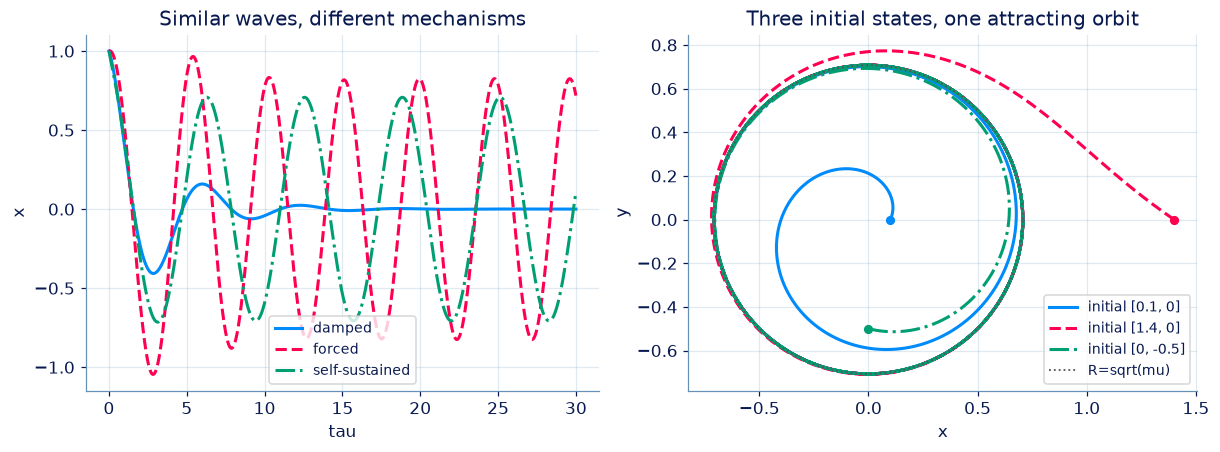

In [4]:
times=np.arange(3001)*.01
decay=np.array(driven_exact(.3,1,0,1.3,[1,0],times))
forced=np.array(driven_exact(.3,1,.35,1.3,[1,0],times))
self_run=np.array(oscillator_path(.5,1,[1,0],.01,3000))
fig,axes=plt.subplots(1,2,figsize=(11,4))
for states,color,style,name in [(decay,BLUE,'-','damped'),(forced,PINK,'--','forced'),(self_run,GREEN,'-.','self-sustained')]:
    axes[0].plot(times,states[:,0],color=color,ls=style,label=name)
for initial,color,style in [([.1,0],BLUE,'-'),([1.4,0],PINK,'--'),([0,-.5],GREEN,'-.')]:
    states=np.array(oscillator_path(.5,1,initial,.01,3000))
    axes[1].plot(states[:,0],states[:,1],color=color,ls=style,label=f'initial {initial}')
    axes[1].scatter(*initial,color=color,s=25)
theta=np.linspace(0,2*np.pi,301)
axes[1].plot(np.sqrt(.5)*np.cos(theta),np.sqrt(.5)*np.sin(theta),color=GRAY,ls=':',lw=1.2,label='R=sqrt(mu)')
axes[0].set(xlabel='tau',ylabel='x',title='Similar waves, different mechanisms')
axes[1].set(xlabel='x',ylabel='y',title='Three initial states, one attracting orbit',aspect='equal')
for ax in axes:ax.legend(fontsize=9)
plt.show()

## 结果解释

左图三种机制使用相同时间尺度（time scale）和初值，右图只比较自维持模型的多个初值，圆点标起点。右图的角度可以不同，轨道半径却趋于同一值。去掉外部驱动的受迫模型会衰减，自维持模型没有可供“关闭”的周期驱动项。

可改变 μ 或初始半径，先用 R′ 的符号预测，再看轨迹（trajectory）；下一节将把“看起来周期”转为有规则的测量。

### 独立核对

先比较笛卡尔中点积分与径向闭式，再将步长减半，检查数值误差（numerical error）怎样变化。

In [5]:
reference=np.array(radial_exact(.5,1,[1,0],times))
coarse=np.max(abs(self_run-reference))
fine=np.array(oscillator_path(.5,1,[1,0],.005,6000))[::2]
fine_error=np.max(abs(fine-reference))
assert coarse>3*fine_error
assert np.max(abs(np.linalg.norm(reference,axis=1)-np.sqrt(np.sum(reference**2,axis=1))))<1e-14
assert radial_exact(.5,1,[0,0],[0,30])==[[0.,0.],[0.,0.]]
print(f'中点法误差 {coarse:.6g}；半步长误差 {fine_error:.6g}；精确原点保持。')

中点法误差 0.000341516；半步长误差 8.52135e-05；精确原点保持。


[观察本章的动态可视化](http://127.0.0.1:8000/chapters/04-02-自维持振荡与极限环/explore/)：先预测条件变化的后果，再用交互对照本节推导。

### 从集合吸引理解恢复

回扣上一章的点到集合距离：下面的稳定圆周吸引非零初值，但沿圆周的运动仍在继续。两次扰动后的振幅恢复不意味着相位（phase）也恢复；纯旋转保持半径，提供不吸引邻近圆周的反例。 [复习吸引集合](../01-多稳态与吸引域/03-从吸引状态到吸引集合.ipynb)。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · 单项选择题：周期曲线是否说明自维持振荡

一段时间曲线在多周期内保持振幅（amplitude）。还需什么信息来判断是否自维持？

- **A.** 应检查是否有周期驱动、去除驱动后的行为，以及多个初值（initial condition）的长期轨迹（trajectory）。
- **B.** 只要两次峰值相同就是极限环（limit cycle）。
- **C.** 测量更密即可替代输入（input）信息。
- **D.** 只需曲线足够平滑。

[作答：周期曲线是否说明自维持振荡](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-oscillation-source)

### 第 2 题 · Python 计算题：从半径与角度恢复二维轨迹

径向振子满足 R′=μR−R³、θ′=ω。给定二维初值（initial condition），按解析式计算状态（state），不能把负分量当作负浓度（concentration）。

**函数与代码模板**

```python
def solve(
    mu: float,
    omega: float,
    initial: list[float],
    times: list[float],
) -> list[list[float]]:
    # 根据已知条件计算，并按约定顺序返回。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `mu` | `float` | 线性径向增长系数 μ。 | 1 |
| `omega` | `float` | 角度增长率 ω。 | 1 |
| `initial` | `list[float]` | 二维无量纲（dimensionless）偏差 [x0,y0]。 | 1 |
| `times` | `list[float]` | 无量纲时刻。 | 1 |

**返回值**

直接返回 states（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `states` | `list[list[float]]` | 依次返回 [x(t),y(t)]。 | 1 |

**计算规则**

s0=x0²+y0²。s0=0 时状态全零；μ=0 时 s=s0/(1+2s0*t)；否则 s=s0*exp(2μt)/(1+s0*expm1(2μt)/μ)。以 sqrt(s/s0) 缩放初值旋转 ωt 后的向量（vector）。

**约束与边界**

- 所有输入（input）数值有限；不修改输入列表。
- −0.5≤mu≤0.8；0<omega≤2；initial 长度为 2，分量绝对值≤2；times 长度 1—30，时刻在 [0,30]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| mu | 线性径向增长系数 μ。 | 0.25 | 1 |
| omega | 角度增长率 ω。 | 1 | 1 |
| initial | 二维无量纲（dimensionless）偏差 [x0,y0]。 | [0.5, 0] | 1 |
| times | 无量纲时刻。 | [0, 1.5707963267948966, 3.141592653589793] | 1 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
mu = 0.25
omega = 1
initial = [0.5, 0]
times = [0, 1.5707963267948966, 3.141592653589793]

result = solve(mu, omega, initial, times)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| states | 依次返回 [x(t),y(t)]。 | [[0.5, 0.0], [3.061616997868383e-17, 0.5], [-0.5, 6.123233995736766e-17]] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.5, 0.0],
                   [3.061616997868383e-17, 0.5],
                   [-0.5, 6.123233995736766e-17]]
```

**样例解释**

初始半径 0.5 正好等于 sqrt(μ)，半径保持不变；三个时刻分别接近 [0.5,0]、[0,0.5]、[−0.5,0]。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从半径与角度恢复二维轨迹](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-radial-solution)

### 第 3 题 · 单项选择题：移除周期驱动以后

阻尼系统 z′=(−α+iω)z+F exp(iΩt)，α>0。在某时刻把 F 改为 0。哪个结论成立？

- **A.** Ω 会自动变成系统的自激频率。
- **B.** 之后仍由周期驱动维持固定振幅（amplitude）。
- **C.** 之后从当时状态（state）开始按 exp(−αΔt) 衰减。
- **D.** 状态必须立刻变为 0。

[作答：移除周期驱动以后](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-forcing-removed)

### 第 4 题 · 单项选择题：为什么正增长系数仍可能不动

径向振子 μ>0，二维初值（initial condition）精确为 [0,0]。哪项正确？

- **A.** 它必定立刻进入极限环（limit cycle）。
- **B.** 它保持在不稳定平衡（equilibrium）；非零小扰动才会离开。
- **C.** μ>0 说明原点稳定。
- **D.** 程序必须添加噪声才能算正确。

[作答：为什么正增长系数仍可能不动](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-origin-exception)

### 第 5 题 · 多项选择题：径向方程怎样支持极限环

对于 μ>0、ω>0 的径向振子，哪些论证成立？

- **A.** R>sqrt(μ) 时半径下降。
- **B.** 在 R=sqrt(μ) 上有周期运动，且邻近非零半径趋向它。
- **C.** 所有初值（initial condition）在同一时刻收敛到同一个状态（state）点。
- **D.** 0<R<sqrt(μ) 时半径增长。

[作答：径向方程怎样支持极限环](http://127.0.0.1:8000/chapters/04-02-%E8%87%AA%E7%BB%B4%E6%8C%81%E6%8C%AF%E8%8D%A1%E4%B8%8E%E6%9E%81%E9%99%90%E7%8E%AF/practice/?question=p04-radial-stability)